In [87]:
#preparation

import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
import statsmodels.formula.api as smf

from pathlib import Path
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_curve, roc_auc_score

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 120)


In [88]:
print("CWD:", os.getcwd())
print("FILES:", os.listdir())

CWD: /Users/K2/anaconda_projects/091d23ff-365e-48f7-8ac9-3729450ac3ab
FILES: ['interaction_model.txt', 'Performance_without_understanding_under_GenAI.ipynb', '.DS_Store', 'RQ1_descriptives.csv', 'df_joint_clean.csv', 'describe_coder2_sample.csv', 'figures', 'study_1_ai_data.csv', '.ipynb_checkpoints', 'LogicData_deidentified.csv', 'Performance_without_understanding_under_GenAI']


In [89]:
dfNAI = pd.read_csv(
    "LogicData_deidentified.csv",
    encoding="latin1",
    encoding_errors="replace"
)

dfAI = pd.read_csv(
    "study_1_ai_data.csv",
    encoding="utf-8",
    encoding_errors="replace"
)


In [90]:
dfNAI.columns

Index(['StartDate', 'EndDate', 'Progress', 'Duration (in seconds)', 'Finished',
       'RecordedDate', 'consent', 'attcheck1', 'attcheck2', 'attcheck12',
       'attcheck22', 'logicAssess0_1', 'absAssess0', 'relAssess0_1',
       'diffSelf0_1', 'diffOther0_1', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7',
       'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17',
       'Q18', 'Q19', 'Q20', 'logicAssess1_1', 'absAssess1', 'relAssess1_1',
       'diffSelf1_1', 'diffOther1_1', 'age', 'gender', 'gender_3_TEXT', 'race',
       'race_6_TEXT', 'education', 'numSemesters', 'fluentEnglish',
       'profession', 'lawSchool', 'LSAT', 'SC0', 'workerId', 'workerID',
       'random', 'score', 'relAssess0', 'relAssess1', 'diffSelf0', 'diffSelf1',
       'diffOther0', 'diffOther1', 'grammarAssess0', 'grammarAssess1'],
      dtype='object')

In [91]:
dfAI.columns

Index(['Unnamed: 0', 'consent', 'attn_check_1', 'attn_check_2',
       'pre_assess_task_comparison', 'pre_assess_task_n_expected_ai',
       'pre_assess_task_n_expected_noai', 'pre_assess_task_ai_comparison',
       'pre_assess_task_n_expected_corr', 'pre_assess_general_comparison',
       ...
       'section_8_len_ms', 'section_18_len_ms', 'section_15_len_ms',
       'section_24_len_ms', 'section_25_len_ms', 'section_26_len_ms',
       'section_27_len_ms', 'section_28_len_ms', 'section_29_len_ms',
       'section_30_len_ms'],
      dtype='object', length=131)

In [92]:
dfNAI.head()

,StartDate,EndDate,Progress,Duration (in seconds),Finished,RecordedDate,consent,attcheck1,attcheck2,attcheck12,attcheck22,logicAssess0_1,absAssess0,relAssess0_1,diffSelf0_1,diffOther0_1,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,logicAssess1_1,absAssess1,relAssess1_1,diffSelf1_1,diffOther1_1,age,gender,gender_3_TEXT,race,race_6_TEXT,education,numSemesters,fluentEnglish,profession,lawSchool,LSAT,SC0,workerId,workerID,random,score,relAssess0,relAssess1,diffSelf0,diffSelf1,diffOther0,diffOther1,grammarAssess0,grammarAssess1
0,6/5/19 7:24,6/5/19 7:34,100,574,True,6/5/19 7:34,I consent to participate in this study.,Logical reasoning,The best choice,NaN,NaN,57,12,57,8,7,Truman Capote wrote In Cold Blood as a result of a series of brutal slayings by two crazed killers.,Federal pay is out of line.,No high jumper entered the meet.,"Therefore, if the overweight men between 25 and 50 were to lose weight, their risk of heart disease would be reduced.",Some brilliant mathematicians donÛªt require calculators for simple multiplication facts.,Women might be more capable than men in math.,the powerful can often avoid serious criminal sentences,"When a university finishes admitting entering students, the freshman class is complete. Since the freshman class is...",sign ordinances are effective,being prepared will be favorable to those who take chances,we may prefer to live safely,Good people may not necessarily have good sense.,the lie detector is a useless device,citing the number of cases in which the lie detector mistook falsehood for truth,The methodology used by investigative critics of the lie detector is itself highly flawed.,Some sportscars need repair every two weeks.,disapproving,the soil not becoming dry and hard,"Postage rates rose over a hundred percent from 1983 to 1993, but the cost of first class mail is still cheaper in th...",will definitely not pass the course,53,6,39,8,6,35.0,Man,NaN,White,NaN,Bachelor's degree in college (4-year),5 or more,"Yes, native monolingual English speaker","Farming, Fishing, and Forestry Occupations",No,No,7,NaN,NaN,5013,7,57,39,8,8,7,6,57,53
1,6/5/19 7:24,6/5/19 7:34,100,587,True,6/5/19 7:34,I consent to participate in this study.,Logical reasoning,The best choice,NaN,NaN,75,9,67,6,8,Truman Capote wrote In Cold Blood as a result of a series of brutal slayings by two crazed killers.,Federal pay is out of line.,No track club members entered the meet.,"Therefore, if the overweight men between 25 and 50 were to lose weight, their risk of heart disease would be reduced.",Some brilliant mathematicians donÛªt require calculators for simple multiplication facts.,Women might be more capable than men in math.,the powerful can often avoid serious criminal sentences,"When silverware is used at the dining table, we usually have guests. Today we have guests, so we are using the silv...",the town looking like Alice in Wonderland is undesirable,being prepared will be favorable to those who take chances,consequentiality is not safe,The common good is not necessarily best for everyone.,a lie detector is often inaccurate,demonstrating that oneÛªs awareness of truth or falsity is always undetectable,The very threat of a lie-detector test has led to a significant number of criminals to confess.,Danish automobiles also leak oil.,disapproving,the gophers not ravaging remaining vegetation,"Postage rates rose over a hundred percent from 1983 to 1993, but the cost of first class mail is still cheaper in th...",will definitely pass the course,53,11,68,8,6,29.0,Woman,NaN,Black or African American,NaN,Bachelor's degree in college (4-year),5 or more,"Yes, native monolingual English speaker",Sales and Related Occupations,No,No,7,NaN,NaN,6996,7,67,68,6,8,8,6,75,53
2,6/5/19 7:27,6/5/19 7:35,100,473,True,6/5/19 7:35,I consent to participate in this study.,Logical reasoning,The best choice,NaN,NaN,74,16,78,5,6,Truman Capote wrote In Cold Blood as a result of a series of brutal slayings by two crazed ki

In [93]:
dfAI.head()

,Unnamed: 0,consent,attn_check_1,attn_check_2,pre_assess_task_comparison,pre_assess_task_n_expected_ai,pre_assess_task_n_expected_noai,pre_assess_task_ai_comparison,pre_assess_task_n_expected_corr,pre_assess_general_comparison,pre_assess_general_difficulty_self,pre_assess_general_difficulty_others,4.1,4.2,5.1,5.2,6.1,6.2,7.1,7.2,8.1,8.2,9.1,9.2,10.1,10.2,11.1,11.2,12.1,12.2,13.1,13.2,14.1,14.2,15.1,15.2,16.1,16.2,17.1,17.2,18.1,18.2,19.1,19.2,20.1,20.2,21.1,21.2,22.1,22.2,23.1,23.2,describe_use,post_assess_task_comparison,post_assess_task_n_expected_ai,post_assess_task_n_expected_noai,post_assess_task_ai_comparison,post_assess_task_n_expected_corr,post_assess_general_comparison,post_assess_general_difficulty_self,...,snail_f1_v33,snail_f1_v22,snail_f1_v36,snail_f1_v05,snail_f2_v35,snail_f2_v34,snail_f2_v25,snail_f2_v08,snail_f2_v06,snail_f2_v39,snail_f2_v28,snail_f2_v21,snail_f2_v20,snail_f2_v32,snail_f3_v37,snail_f3_v02,snail_f3_v01,snail_f3_v31,snail_f3_v24,snail_f3_v29,snail_f3_v19,age,gender,education,uni_semesters,eng_fluency,profession,lsat_taken,pid,attn_check_ok,section_1_len_ms,section_2_len_ms,section_3_len_ms,section_20_len_ms,section_19_len_ms,section_21_len_ms,section_4_len_ms,section_13_len_ms,section_12_len_ms,section_9_len_ms,section_5_len_ms,section_16_len_ms,section_7_len_ms,section_22_len_ms,section_6_len_ms,section_10_len_ms,section_17_len_ms,section_23_len_ms,section_11_len_ms,section_14_len_ms,section_8_len_ms,section_18_len_ms,section_15_len_ms,section_24_len_ms,section_25_len_ms,section_26_len_ms,section_27_len_ms,section_28_len_ms,section_29_len_ms,section_30_len_ms
0,0,"Yes, I have read the information above and agree to take part in this study",Logical reasoning,The best choice,86,20,15,95,20,81,3,5,"Soon after the advent of color television, white shirts became less popular as dressy attire for men, and pastel-col...",95,Federal pay is out of line.,89,No high jumper entered the meet.,91,"Therefore, if the overweight men between 25 and 50 were to lose weight, their risk of heart disease would be reduced.",84,Only computer geniuses are also brilliant mathematicians.,97,Women tend to conform to social expectations.,90,the powerful can often avoid serious criminal sentences,98,"When the dog has fleas, he always scratches. But the dog doesn’t have fleas, so he won’t be scratching.",94,"sign ordinances are rarely, if ever effective",98,happenstance will be more beneficial to those who are prepared,98,doing nothing has lesser consequences,97,Good people may not necessarily have good sense.,95,a good liar can fool the device,94,demonstrating that one’s awareness of truth or falsity is always undetectable,99,The very threat of a lie-detector test has led to a significant number of criminals to confess.,93,Danish automobiles also leak oil.,96,disapproving,87,water conservation,98,Late-night vandalism has plagued post offices nationwide.,94,may or may not pass the course,65,I copied the question and try and made my conclusion from the answer given.,86,20,14,89,20,92,1,...,6,6,6,4,7,6,6,5,2,3,6,6,6,5,6,5,6,7,6,6,5,44,Female,Lower tertiary education degree (Bachelor's level),8,Native English speaker,manager,No,664206d50545fd91121b81e2,True,27959,302089,59953,69625,59844,56187,46631,46266,78948,24752,33584,21723,34464,43728,31477,28608,21919,98349,79708,32348,34695,26248,36307,4767,45068,40635,49170,25516,13270,43237
1,0,"Yes, I have read the information above and agree to take part in this study",Logical reasoning,The best choice,79,20,15,70,20,77,5,5,"Soon after the advent of color television, white shirts became less popular as dressy attire for men, and pastel-col...",100,Federal pay is out of line.,100,No high jumper entered the meet.,100,"Therefore, if the overweight men between 25 and 50 were to lose weight, their risk of heart disease would be reduced.",100,Some brilliant mathematicians require calculators for simple multiplication facts.,91,Women tend to conform to social expectations.,100,the powerful c

In [94]:
#clean data

In [95]:
dfNAI = pd.read_csv("LogicData_deidentified.csv", encoding_errors="replace")
dfNAI = dfNAI[dfNAI["score"].notna()]    #Remove rows with missing scores
dfNAI = dfNAI[dfNAI["absAssess1"].notna()]  #Remove rows with missing self-assessments
dfNAI.shape


(3543, 65)

In [96]:
dfAI[["attn_check_1","attn_check_2"]].astype(str).head(10)


,attn_check_1,attn_check_2
0,Logical reasoning,The best choice
1,Logical reasoning,The best choice
2,Logical reasoning,The best choice
3,Logical reasoning,The best choice
4,Logical reasoning,The best choice
5,Logical reasoning,The best choice
6,Logical reasoning,The best choice
7,Logical reasoning,The best choice
8,Logical reasoning,The best choice
9,Logical reasoning,The best choice


In [97]:
dfAI = pd.read_csv(
    "study_1_ai_data.csv",
    encoding="utf-8",
    encoding_errors="replace"
)


dfAI = dfAI.drop_duplicates(subset="pid")
dfAI = dfAI[dfAI["pre_assess_task_n_expected_ai"].notna()]


def norm(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()


dfAI["attn1_norm"] = dfAI["attn_check_1"].apply(norm)
dfAI["attn2_norm"] = dfAI["attn_check_2"].apply(norm)


dfAI = dfAI[
    (dfAI["attn1_norm"] == "logical reasoning") &
    (dfAI["attn2_norm"] == "the best choice")
].copy()

print("AI (after attention check):", dfAI.shape[0])
dfAI.shape


AI (after attention check): 261


(261, 133)

In [98]:
print("score" in dfNAI.columns, "absAssess1" in dfNAI.columns)

True True


In [99]:
# variable construction

In [100]:
#group dfNAI reconstruction
dfNAI = dfNAI[dfNAI["score"].notna() & dfNAI["absAssess1"].notna()].copy()
dfNAI["Estimate"] = pd.to_numeric(dfNAI["absAssess1"], errors="coerce")
dfNAI["bias"] = dfNAI["Estimate"] - dfNAI["score"]       # construct bias    
dfNAI["miscalibration"] = dfNAI["bias"].abs()            #construct miscalibration
dfNAI["overconfident"] = (dfNAI["bias"] > 0).astype(int) #construct overconfident(auxiliary variable)
print("dfNAI after cleaning:", dfNAI.shape)
dfNAI[["score", "Estimate", "bias", "miscalibration"]].describe()



dfNAI after cleaning: (3543, 69)


,score,Estimate,bias,miscalibration
count,3543.000000,3543.000000,3543.000000,3543.000000
mean,9.453853,10.862264,1.408411,3.804121
std,3.590258,4.052478,4.832719,3.296048
min,0.000000,0.000000,-15.000000,0.000000
25%,7.000000,8.000000,-2.000000,1.000000
50%,10.000000,10.000000,1.000000,3.000000
75%,12.000000,14.000000,4.000000,5.000000
max,19.000000,20.000000,19.000000,19.000000


In [101]:
#group dfAI reconstruction

#step 1 score construction  (according to the process of Fernandes's 20241210Analysis_S1.Rmd and translate to python)

right_choices = [
    "Soon after the advent of color television, white shirts became less popular as dressy attire for men, and pastel-colored shirts began to sell well.",
    "Federal pay is out of line.",
    "No high jumper entered the meet.",
    "Therefore, if the overweight men between 25 and 50 were to lose weight, their risk of heart disease would be reduced.",
    "Some brilliant mathematicians require calculators for simple multiplication facts.",
    "Women tend to conform to social expectations.",
    "the powerful can often avoid serious criminal sentences",
    "When the dog has fleas, he always scratches. But the dog doesn’t have fleas, so he won’t be scratching.",
    "sign ordinances are rarely, if ever effective",
    "happenstance will be more beneficial to those who are prepared",
    "not doing anything is not an act",
    "Jumbo shrimp may not actually be very big.",
    "the lie detector is sometimes worthless",
    "citing the number of cases in which the lie detector mistook falsehood for truth",
    "The very threat of a lie-detector test has led to a significant number of criminals to confess.",
    "Danish automobiles also leak oil.",
    "disapproving",
    "water conservation",
    "Ten years ago, most letters reached their destination within twenty-four hours.",
    "may or may not pass the course"
]
len(right_choices)

20

In [102]:

right_lower = [x.lower() for x in right_choices]


def find_response_col(df, i):
    candidates = [f"{i}.1", f"X{i}.1", f"X{i}_1", f"{i}_1"]
    for c in candidates:
        if c in df.columns:
            return c
    pat = re.compile(rf"^(X)?{i}(\.1|_1)$")
    for c in df.columns:
        if pat.match(str(c).strip()):
            return c
    return None

match_cols = []
missing_items = []

for i in range(4, 24):  # 20 items
    col = find_response_col(dfAI, i)
    if col is None:
        missing_items.append(i)
        continue
    mcol = f"X{i}_1_match"
    dfAI[mcol] = dfAI[col].astype(str).str.lower().isin(right_lower)
    match_cols.append(mcol)

print("Missing items:", missing_items)
print("Number of matched items:", len(match_cols))


dfAI["score"] = dfAI[match_cols].sum(axis=1).astype(int)

dfAI["score"].describe()


Missing items: []
Number of matched items: 20


count    261.000000
mean      13.038314
std        2.916542
min        0.000000
25%       13.000000
50%       14.000000
75%       15.000000
max       17.000000
Name: score, dtype: float64

In [103]:
#step 2 group dfAI reconstruction
dfAI["Estimate"] = pd.to_numeric(
    dfAI["post_assess_task_n_expected_ai"], errors="coerce"
)
dfAI = dfAI[dfAI["Estimate"] <= 20].copy()

dfAI["bias"] = dfAI["Estimate"] - dfAI["score"]
dfAI["miscalibration"] = dfAI["bias"].abs()

print("dfAI after reconstruction:", dfAI.shape)
dfAI[["score", "Estimate", "bias", "miscalibration"]].describe()

dfAI after reconstruction: (259, 157)


,score,Estimate,bias,miscalibration
count,259.000000,259.000000,259.000000,259.000000
mean,13.027027,16.509653,3.482625,4.370656
std,2.916679,3.690931,3.898256,2.862763
min,0.000000,0.000000,-10.000000,0.000000
25%,13.000000,15.000000,2.000000,2.000000
50%,14.000000,18.000000,4.000000,4.000000
75%,15.000000,19.000000,5.500000,6.000000
max,17.000000,20.000000,19.000000,19.000000


In [104]:
#merge AI and no-AI groups 

dfAI["group"] = "AI"
dfNAI["group"] = "noAI"

df_joint = pd.concat(
    [
        dfAI[["score", "Estimate", "bias", "miscalibration", "group"]],
        dfNAI[["score", "Estimate", "bias", "miscalibration", "group"]]
    ],
    ignore_index=True
)

df_joint["group"] = df_joint["group"].astype("category")
df_joint.groupby("group", observed=False).size()

group
AI       259
noAI    3543
dtype: int64

In [105]:
#RQ1: Does the use of AI significantly increase the gap between perceived and actual performance?

In [106]:
#Descriptive Statistics
df_joint.groupby("group", observed=False)[["score", "Estimate", "bias", "miscalibration"]].agg(["mean", "std", "count"])

score                   Estimate                      bias  \
            mean       std count       mean       std count      mean   
group                                                                   
AI     13.027027  2.916679   259  16.509653  3.690931   259  3.482625   
noAI    9.453853  3.590258  3543  10.862264  4.052478  3543  1.408411   

                      miscalibration                  
            std count           mean       std count  
group                                                 
AI     3.898256   259       4.370656  2.862763   259  
noAI   4.832719  3543       3.804121  3.296048  3543

In [107]:
#result interpret: Although AI users achieved higher scores, they also exhibited greater positive bias and larger perceived-actual performance gaps than non-AI users


In [108]:
ai_gap = df_joint.loc[df_joint["group"]=="AI", "miscalibration"].dropna()
noai_gap = df_joint.loc[df_joint["group"]=="noAI", "miscalibration"].dropna()


#Welch t-test
welch = stats.ttest_ind(ai_gap, noai_gap, equal_var=False)
welch



TtestResult(statistic=np.float64(3.0409350710857432), pvalue=np.float64(0.0025595937922934294), df=np.float64(310.2133936529193))

In [109]:
#result interpret: A Welch’s independent-samples t-test indicated that the AI group exhibited significantly greater miscalibration than the no-AI group, t(310.21) = 3.04, p = .003. The effect size was small (Cohen’s d = 0.18).

In [110]:
#Robustness Check: Mann–Whitney U
mw = mannwhitneyu(ai_gap, noai_gap, alternative="two-sided")
mw

MannwhitneyuResult(statistic=np.float64(536122.0), pvalue=np.float64(4.942788249981754e-06))

In [111]:
#result interpret: A Welch’s independent-samples t-test showed that the AI group exhibited significantly greater miscalibration than the no-AI group (t = 3.04, p = .003). This result was robust to a nonparametric Mann–Whitney U test (p < .001), although the effect size was small (Cohen’s d = 0.18).

In [112]:
mean_diff = ai_gap.mean() - noai_gap.mean()
mean_diff

np.float64(0.5665355690757892)

In [113]:
#result interpret: On average, AI users exhibited a miscalibration that was about 0.57 points larger than non-AI users 

In [114]:
dfNAI["bias"] = dfNAI["absAssess1"] - dfNAI["score"]
dfNAI["bias"].describe()


count    3543.000000
mean        1.408411
std         4.832719
min       -15.000000
25%        -2.000000
50%         1.000000
75%         4.000000
max        19.000000
Name: bias, dtype: float64

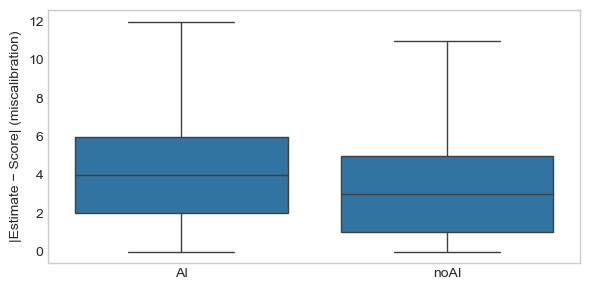

In [115]:
#visualization
plt.figure(figsize=(6,3))
sns.boxplot(data=df_joint, x="group", y="miscalibration", showfliers=False)
plt.xlabel("")
plt.ylabel("|Estimate − Score| (miscalibration)")
plt.grid(False)
plt.tight_layout()
plt.show()

In [116]:
#result interpret: The boxplot shows that the AI group has a systematically higher miscalibration,indicating a larger perceived–actual performance gap, although the distributions largely overlap.

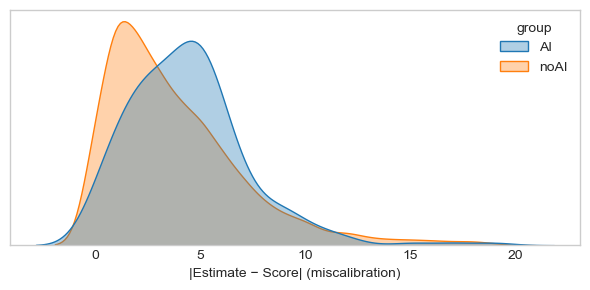

In [117]:
plt.figure(figsize=(6,3))
sns.kdeplot(data=df_joint, x="miscalibration", hue="group", fill=True, common_norm=False, alpha=0.35)
plt.xlabel("|Estimate − Score| (miscalibration)")
plt.ylabel("")
plt.yticks([])
plt.grid(False)
plt.tight_layout()
plt.show()

In [118]:
#result interpret: The results show a statistically reliable rightward shift in miscalibration among AI users, reflecting greater perceived–actual discrepancy and increased epistemic risk at the population level.

In [119]:
# sub-question: performance gains without learning (prior LSAT experience or not)

In [120]:
#regrouping data
def find_lsat_col(df):
    """
    Try to find a column that looks like LSAT experience / prior LSAT exposure.
    You can extend keywords if needed.
    """
    keywords = ["lsat", "logic_game", "logic games", "law school", "prelaw", "test prep", "reasoning experience"]
    cols = df.columns.astype(str)


    hits = []
    for c in cols:
        cl = c.lower()
        if any(k in cl for k in keywords):
            hits.append(c)

    return hits 

lsat_candidates_ai  = find_lsat_col(dfAI)
lsat_candidates_no  = find_lsat_col(dfNAI)

print("AI LSAT-like candidates:", lsat_candidates_ai[:20])
print("noAI LSAT-like candidates:", lsat_candidates_no[:20])


AI LSAT-like candidates: ['lsat_taken']
noAI LSAT-like candidates: ['LSAT']


In [124]:

LSAT_COL_AI  = lsat_candidates_ai[0] if len(lsat_candidates_ai) else None
LSAT_COL_NO  = lsat_candidates_no[0] if len(lsat_candidates_no) else None

print("Using LSAT_COL_AI:", LSAT_COL_AI)
print("Using LSAT_COL_NO:", LSAT_COL_NO)

def to_numeric_experience(s):
    """
    Convert common encodings to numeric.
    - Yes/No, True/False -> 1/0
    - If already numeric (e.g., Likert), keep numeric
    """
    if s is None:
        return None

    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    x = s.astype(str).str.strip().str.lower()

    yes = {"yes", "y", "true", "1", "experienced", "familiar", "have taken", "taken"}
    no  = {"no", "n", "false", "0", "na", "none", "never"}

    out = pd.Series(np.nan, index=s.index, dtype="float")
    out[x.isin(yes)] = 1.0
    out[x.isin(no)]  = 0.0

    # try numeric extraction if still missing (e.g., "3", "4.0")
    out = out.fillna(pd.to_numeric(x, errors="coerce"))
    return out


df_ai_sub  = dfAI.copy()
df_no_sub  = dfNAI.copy()

if LSAT_COL_AI is None or LSAT_COL_NO is None:
    raise ValueError(
        "Could not automatically detect LSAT experience columns. "
        "Please manually set LSAT_COL_AI and LSAT_COL_NO from your column lists."
    )

df_ai_sub["lsat_exp"] = to_numeric_experience(df_ai_sub[LSAT_COL_AI])
df_no_sub["lsat_exp"] = to_numeric_experience(df_no_sub[LSAT_COL_NO])


df_ai_sub = df_ai_sub[df_ai_sub["lsat_exp"].notna() & df_ai_sub["score"].notna()].copy()
df_no_sub = df_no_sub[df_no_sub["lsat_exp"].notna() & df_no_sub["score"].notna()].copy()

print("AI sub shape:", df_ai_sub.shape, "  lsat_exp unique:", df_ai_sub["lsat_exp"].dropna().unique()[:10])
print("noAI sub shape:", df_no_sub.shape, " lsat_exp unique:", df_no_sub["lsat_exp"].dropna().unique()[:10])

Using LSAT_COL_AI: lsat_taken
Using LSAT_COL_NO: LSAT
AI sub shape: (259, 159)   lsat_exp unique: [0. 1.]
noAI sub shape: (3538, 71)  lsat_exp unique: [0. 1.]


In [125]:

df_lsat_desc = df_all.copy() 

df_lsat_desc["lsat_any"] = (df_lsat_desc["lsat_exp"] > 0).astype(int)

lsat_counts = pd.crosstab(
    df_lsat_desc["group"],
    df_lsat_desc["lsat_any"],
    rownames=["Group"],
    colnames=["Prior LSAT experience"]
)

lsat_counts



Prior LSAT experience,0,1
Group,,
AI,245,14
noAI,3383,155


In [126]:
df_ai_sub["group"] = "AI"
df_no_sub["group"] = "noAI"
df_all = pd.concat([df_ai_sub[["score","lsat_exp","group"]],
                    df_no_sub[["score","lsat_exp","group"]]], ignore_index=True)

# interpretation model: score = baseline + group effect + LSAT experience effect(group × LSAT experience interaction)
# The interaction term tells you whether the slope of lsat_exp differs by group.

m_int = smf.ols("score ~ C(group) * lsat_exp", data=df_all).fit(cov_type="HC3")
print(m_int.summary().tables[1])



                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    13.0531      0.186     70.167      0.000      12.688      13.418
C(group)[T.noAI]             -3.5674      0.196    -18.236      0.000      -3.951      -3.184
lsat_exp                     -0.4816      0.901     -0.534      0.593      -2.248       1.285
C(group)[T.noAI]:lsat_exp    -0.1782      0.984     -0.181      0.856      -2.106       1.749


In [127]:
#result interpret: AI significantly increases performance (score), but prior LSAT experience does not significantly predict scores.

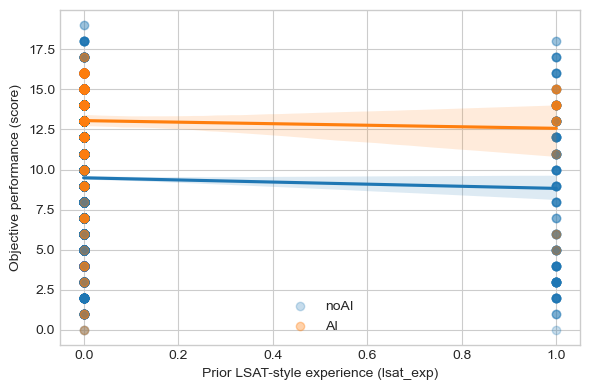

In [128]:
plt.figure(figsize=(6,4))
sns.regplot(data=df_no_sub, x="lsat_exp", y="score", scatter_kws={"alpha":0.25}, label="noAI")
sns.regplot(data=df_ai_sub, x="lsat_exp", y="score", scatter_kws={"alpha":0.35}, label="AI")
plt.xlabel("Prior LSAT-style experience (lsat_exp)")
plt.ylabel("Objective performance (score)")
plt.legend()
plt.tight_layout()
plt.show()


In [129]:
#result interpret: prior LSAT experience does not reliably distinguish high from low performers.This is largely due to sample structure: participants with LSAT experience are very rare, making the estimated regression slopes unstable and driven by a small number of observations.

In [130]:
for d in [df_ai_sub, df_no_sub]:
    if "miscalibration" not in d.columns:
        if "Estimate" in d.columns:
            d["miscalibration"] = (d["Estimate"] - d["score"]).abs()
        else:
            raise ValueError("Estimate not found; cannot compute miscalibration.")

df_all2 = pd.concat([df_ai_sub[["miscalibration","lsat_exp","group"]],
                     df_no_sub[["miscalibration","lsat_exp","group"]]], ignore_index=True)

m_int_gap = smf.ols("miscalibration ~ C(group) * lsat_exp", data=df_all2).fit(cov_type="HC3")
print(m_int_gap.summary().tables[1])


                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     4.3143      0.182     23.737      0.000       3.958       4.671
C(group)[T.noAI]             -0.5957      0.190     -3.141      0.002      -0.967      -0.224
lsat_exp                      1.0429      0.906      1.151      0.250      -0.733       2.819
C(group)[T.noAI]:lsat_exp     0.8902      1.005      0.886      0.376      -1.079       2.859


In [131]:
#result interpret: AI use is associated with larger self-assessment errors, and prior LSAT experience does not systematically reduce miscalibration under AI.

In [ ]:
#RQ2: Does generative AI assistance alter the diagnostic value of self-confidence for correctness in logical reasoning tasks?

In [ ]:
#evidence1:DK quantile plot 

In [ ]:

def dk_quantile_summary(data):
    tmp = data[["score","Estimate"]].dropna().copy()
    tmp["quantile"] = pd.qcut(tmp["score"].rank(method="first"), q=4, labels=False) + 1
    return tmp.groupby("quantile", as_index=False).agg(
        mu_obj=("score","mean"),
        mu_per=("Estimate","mean")
    )

def plot_dk(data, title, color_per):
    s = dk_quantile_summary(data)
    plt.plot(s["quantile"], s["mu_obj"], marker="o", linewidth=2, color="black", label="Achieved")
    plt.plot(s["quantile"], s["mu_per"], marker="o", linewidth=2, color=color_per, label="Estimated")
    plt.ylim(0, 20)
    plt.xticks([1,2,3,4])
    plt.xlabel("Quantile (by achieved score)")
    plt.ylabel("Average score")
    plt.title(title)
    plt.grid(False)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1); plot_dk(dfNAI, "noAI", color_per="#8F2727")
plt.subplot(1,2,2); plot_dk(dfAI,  "AI",   color_per="blue")
plt.tight_layout()
plt.show()

In [ ]:
#result interpret: The DK plots indicate that miscalibration decreases with performance in the no-AI condition but remains largely constant across performance quantiles in the AI condition.

In [ ]:
#evidence 2 Compared to non-AI users，do AI users exhibit different levels of confidence when answering correctly versus incorrectly?

In [ ]:
#construct dfNAI_long
dfNAI.shape
dfNAI.columns

In [ ]:
#The no-AI group (Jansen dataset) does not contain item-level confidence ratings or item-level correctness information

In [ ]:
#construct dfAI_long
print(dfAI.columns.tolist())

In [ ]:
def find_col(df, i, suffix):

    candidates = [
        f"X{i}.{suffix}",
        f"{i}.{suffix}",
        f"X{i}_{suffix}",
        f"{i}_{suffix}"
    ]
    for c in candidates:
        if c in df.columns:
            return c

    pat = re.compile(rf"^(X)?{i}(\.|_){suffix}$")
    for c in df.columns:
        if pat.match(str(c).strip()):
            return c

    return None

In [ ]:
rows = []

for i in range(4, 24):
    conf_col = find_col(dfAI, i, 2)    
    corr_col = f"X{i}_1_match"        

    if conf_col is None or corr_col not in dfAI.columns:
        continue

    tmp = dfAI[["pid", conf_col, corr_col]].copy()
    tmp.columns = ["pid", "confidence", "correctness"]
    tmp["item"] = i
    rows.append(tmp)

df_long = pd.concat(rows, ignore_index=True)
df_long["correctness"] = df_long["correctness"].astype(int)

df_long.head(20)

In [ ]:
df_long["correctness"].value_counts()

In [ ]:
df_long["confidence"].describe()

In [ ]:
df_long.groupby("correctness")["confidence"].mean()

In [ ]:
conf_correct = df_long.loc[df_long["correctness"] == 1, "confidence"]
conf_wrong   = df_long.loc[df_long["correctness"] == 0, "confidence"]

stats.ttest_ind(conf_correct, conf_wrong, equal_var=False)

In [ ]:
#result interpret:Confidence was significantly higher for correct than incorrect responses, t(3204.57) = 10.71, p < .001, indicating that participants’ confidence reliably tracked correctness at the item level.

In [ ]:
# rq3: What patterns of reliance on generative AI emerge when solving logical reasoning tasks?


In [135]:
df_describe = pd.read_csv(
    "study_1_ai_data.csv",
    encoding="utf-8",
    encoding_errors="replace"
)

print(df_describe.shape)
df_describe.head(20)

(274, 131)


,Unnamed: 0,consent,attn_check_1,attn_check_2,pre_assess_task_comparison,pre_assess_task_n_expected_ai,pre_assess_task_n_expected_noai,pre_assess_task_ai_comparison,pre_assess_task_n_expected_corr,pre_assess_general_comparison,pre_assess_general_difficulty_self,pre_assess_general_difficulty_others,4.1,4.2,5.1,5.2,6.1,6.2,7.1,7.2,8.1,8.2,9.1,9.2,10.1,10.2,11.1,11.2,12.1,12.2,13.1,13.2,14.1,14.2,15.1,15.2,16.1,16.2,17.1,17.2,18.1,18.2,19.1,19.2,20.1,20.2,21.1,21.2,22.1,22.2,23.1,23.2,describe_use,post_assess_task_comparison,post_assess_task_n_expected_ai,post_assess_task_n_expected_noai,post_assess_task_ai_comparison,post_assess_task_n_expected_corr,post_assess_general_comparison,post_assess_general_difficulty_self,...,snail_f1_v33,snail_f1_v22,snail_f1_v36,snail_f1_v05,snail_f2_v35,snail_f2_v34,snail_f2_v25,snail_f2_v08,snail_f2_v06,snail_f2_v39,snail_f2_v28,snail_f2_v21,snail_f2_v20,snail_f2_v32,snail_f3_v37,snail_f3_v02,snail_f3_v01,snail_f3_v31,snail_f3_v24,snail_f3_v29,snail_f3_v19,age,gender,education,uni_semesters,eng_fluency,profession,lsat_taken,pid,attn_check_ok,section_1_len_ms,section_2_len_ms,section_3_len_ms,section_20_len_ms,section_19_len_ms,section_21_len_ms,section_4_len_ms,section_13_len_ms,section_12_len_ms,section_9_len_ms,section_5_len_ms,section_16_len_ms,section_7_len_ms,section_22_len_ms,section_6_len_ms,section_10_len_ms,section_17_len_ms,section_23_len_ms,section_11_len_ms,section_14_len_ms,section_8_len_ms,section_18_len_ms,section_15_len_ms,section_24_len_ms,section_25_len_ms,section_26_len_ms,section_27_len_ms,section_28_len_ms,section_29_len_ms,section_30_len_ms
0,0,"Yes, I have read the information above and agree to take part in this study",Logical reasoning,The best choice,86,20,15,95,20,81,3,5,"Soon after the advent of color television, white shirts became less popular as dressy attire for men, and pastel-col...",95,Federal pay is out of line.,89,No high jumper entered the meet.,91,"Therefore, if the overweight men between 25 and 50 were to lose weight, their risk of heart disease would be reduced.",84,Only computer geniuses are also brilliant mathematicians.,97,Women tend to conform to social expectations.,90,the powerful can often avoid serious criminal sentences,98,"When the dog has fleas, he always scratches. But the dog doesn’t have fleas, so he won’t be scratching.",94,"sign ordinances are rarely, if ever effective",98,happenstance will be more beneficial to those who are prepared,98,doing nothing has lesser consequences,97,Good people may not necessarily have good sense.,95,a good liar can fool the device,94,demonstrating that one’s awareness of truth or falsity is always undetectable,99,The very threat of a lie-detector test has led to a significant number of criminals to confess.,93,Danish automobiles also leak oil.,96,disapproving,87,water conservation,98,Late-night vandalism has plagued post offices nationwide.,94,may or may not pass the course,65,I copied the question and try and made my conclusion from the answer given.,86,20,14,89,20,92,1,...,6,6,6,4,7,6,6,5,2,3,6,6,6,5,6,5,6,7,6,6,5,44,Female,Lower tertiary education degree (Bachelor's level),8,Native English speaker,manager,No,664206d50545fd91121b81e2,True,27959,302089,59953,69625,59844,56187,46631,46266,78948,24752,33584,21723,34464,43728,31477,28608,21919,98349,79708,32348,34695,26248,36307,4767,45068,40635,49170,25516,13270,43237
1,0,"Yes, I have read the information above and agree to take part in this study",Logical reasoning,The best choice,79,20,15,70,20,77,5,5,"Soon after the advent of color television, white shirts became less popular as dressy attire for men, and pastel-col...",100,Federal pay is out of line.,100,No high jumper entered the meet.,100,"Therefore, if the overweight men between 25 and 50 were to lose weight, their risk of heart disease would be reduced.",100,Some brilliant mathematicians require calculators for simple multiplication facts.,91,Women tend to conform to social expectations.,100,the powerful c

In [136]:
# step 1: find describe_use
use_candidates = [c for c in df_describe.columns if "describe" in c.lower() and "use" in c.lower()]
use_candidates += [c for c in df_describe.columns if "use" in c.lower() and "describe" in c.lower()]
use_candidates = list(dict.fromkeys(use_candidates))

print("describe_use candidates:", use_candidates)


USE_COL = use_candidates[0] if len(use_candidates) else "describe_use"
print("Using USE_COL =", USE_COL)

# step 2: find PID 
pid_candidates = [c for c in df_describe.columns if c.lower() in ["pid","participant_id","prolific_pid","participantid"]]
PID_COL = pid_candidates[0] if len(pid_candidates) else None
print("PID_COL =", PID_COL)

# step 3: find score and estimate 
print("Has score?", "score" in df_describe.columns)
print("Has Estimate?", "Estimate" in df_describe.columns)


describe_use candidates: ['describe_use']
Using USE_COL = describe_use
PID_COL = pid
Has score? False
Has Estimate? False


In [137]:
# data cleaning again and again and again...

def clean_text(x):
    if pd.isna(x):
        return ""
    x = x.lower()
    x = re.sub(r"\s+", " ", x)
    return x.strip()

df_describe["describe_clean"] = df_describe["describe_use"].apply(clean_text)

df_describe["describe_clean"].head(5)


0        i copied the question and try and made my conclusion from the answer given.
1               i made the ai aware we are about to solve logical reasoning problems
2                            i prompted the chat bot to help me solve the challenges
3    some specific typing and asking questions, but mostly copy and paste responses.
4                                          i told ai chatbot what we are about to do
Name: describe_clean, dtype: object

In [ ]:
# Research qustion 3 will be continue in another notebook

In [ ]:
#output

In [ ]:

rq1_desc = (
    df_joint
    .groupby("group", observed=False)[["score","Estimate","bias","miscalibration"]]
    .agg(["mean","std","count"])
)


rq1_desc_flat = rq1_desc.copy()
rq1_desc_flat.columns = ["_".join(col).strip() for col in rq1_desc_flat.columns.to_flat_index()]
rq1_desc_flat = rq1_desc_flat.reset_index()

rq1_desc_flat.to_csv("RQ1_descriptives.csv", index=False, encoding="utf-8-sig")


In [ ]:
df_joint.to_csv("df_joint_clean.csv", index=False, encoding="utf-8-sig")

In [ ]:
with open("interaction_model.txt", "w", encoding="utf-8") as f:
    f.write(m_int.summary().as_text())

In [ ]:
os.makedirs("figures", exist_ok=True)

plt.savefig("figures/Fig1_miscalibration_boxplot.pdf", bbox_inches="tight")
plt.savefig("figures/Fig1_miscalibration_boxplot.png", dpi=300, bbox_inches="tight") 


In [ ]:
os.getcwd()